# Pochopenie dát – CDI počas vĺn pandémie
Táto časť slúži na:
- načítanie dát zo štyroch vĺn a zjednotenie do jedného datasetu,
- základné čistenie (True/False → 0/1, numerické konverzie),
- deskriptívne štatistiky a vizualizácie
- analýzu demografie, komorbidít, laboratórií a liekov vo vzťahu ku CDI.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path


SHOW = True           
DPI  = 200

# Štýl grafov
plt.style.use("seaborn-v0_8-whitegrid")
PRIMARY = "#1e8fa4"
SECONDARY = "#32c1a8"

# Cesta k dátam 
DATA_DIR = Path("data")
FILES = {
    "Wuhan":   DATA_DIR / "wuhan.csv",
    "Alfa":    DATA_DIR / "alfa.csv",
    "Delta":   DATA_DIR / "delta.csv",
    "Omikron": DATA_DIR / "omikron.csv",
}

## Načítanie dát zo štyroch vĺn a zjednotenie
- Každý CSV súbor predstavuje jednu vlnu pandémie.
- Pridá sa stĺpec `Vlna`.
- Cieľový atribút: `A04.7` (CDI; 0/1).

In [3]:
def read_csv_auto(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, sep=";", encoding="utf-8", low_memory=False)

dfs = []
for wave, file in FILES.items():
    df = read_csv_auto(file)
    df["Vlna"] = wave
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# CDI status label pre grafy
if "A04.7" not in data.columns:
    raise ValueError("Chýba stĺpec A04.7 v dátach.")

data["A04.7"] = pd.to_numeric(data["A04.7"], errors="coerce").fillna(0).astype(int)
data["CDI_status"] = data["A04.7"].map({0: "CDI−", 1: "CDI+"})

# Poradie vĺn
WAVE_ORDER = ["Wuhan", "Alfa", "Delta", "Omikron"]
data["Vlna"] = pd.Categorical(data["Vlna"], categories=WAVE_ORDER, ordered=True)

data.shape, data["Vlna"].value_counts(dropna=False)

((3848, 276),
 Vlna
 Omikron    1251
 Wuhan      1124
 Alfa        824
 Delta       649
 Name: count, dtype: int64)

## Odhalenie chýbajúcich hodnôt
Zobrazí sa tabuľka s počtom a percentom chýbajúcich hodnôt pre každý atribút.

In [4]:
missing_summary = (
    data.isna().sum()
    .reset_index()
    .rename(columns={"index": "Atribút", 0: "Počet_prázdnych"})
)
missing_summary["Percento_prázdnych"] = (missing_summary["Počet_prázdnych"] / len(data) * 100).round(2)
missing_summary = missing_summary.sort_values(by="Počet_prázdnych", ascending=False)

display(missing_summary.head(500))

,Atribút,Počet_prázdnych,Percento_prázdnych
23,Unnamed: 23,3848,100.00
47,S-Chol first,3710,96.41
50,S-Chol max,3710,96.41
49,S-Chol min,3710,96.41
48,S-Chol last,3710,96.41
...,...,...,...
218,9547D | PAXLOVID,0,0.00
217,5042D | VEKLURY,0,0.00
216,MD656 IV-BECT 6MG (ivermectin),0,0.00
215,MD652 | FABIFLU TABLETS,0,0.00


## Základné čistenie dát
- Automatická konverzia stĺpcov typu True/False na 0/1.

In [5]:
def to_01(series: pd.Series) -> pd.Series:
    s_str = series.astype(str).str.strip().str.lower()
    s_map = s_str.map({"true": 1, "false": 0})
    s_map[s_str.isin(["nan", "", "none"])] = np.nan
    return s_map

bool_like_cols = []
for col in data.columns:
    vals = data[col].dropna().astype(str).str.strip().str.lower().unique()
    if len(vals) > 0 and set(vals).issubset({"true", "false"}):
        data[col] = to_01(data[col])
        bool_like_cols.append(col)

print("Počet CDI pozitívnych:", int(data["A04.7"].sum()))
print("Počet CDI negatívnych:", int(len(data) - data["A04.7"].sum()))
print(f"Bool-like stĺpce prevedené na 0/1 (n={len(bool_like_cols)}):")
print(bool_like_cols[:40], "..." if len(bool_like_cols) > 40 else "")

Počet CDI pozitívnych: 103
Počet CDI negatívnych: 3745
Bool-like stĺpce prevedené na 0/1 (n=62):
['Fajčenie', 'Alkohol', 'Hypertenzia', 'Diabetes mellitus', 'Kardiovaskulárne ochorenia', 'Chronické respiračné ochorenia', 'Renálne ochorenia', 'Pečeňové ochorenia', 'Onkologické ochorenia', 'Imunosupresia', 'Vakcinácia', 'MD652 | FABIFLU TABLETS', 'MD656 IV-BECT 6MG (ivermectin)', '5042D | VEKLURY', '9547D | PAXLOVID', 'LAGEVRIO', '00584 | PYRIDOXIN LÉČIVA INJ', '24836 | ACIDUM ASCORBICUM BBP', '24814 | CALCIFEROL BBP 7,5 MG/ML', '00498 | MAGNESIUM SULFURICUM BBP 100 MG/ML INJEKČNÝ ROZTOK', '00449 | EREVIT 300 MG/ML', '89145 | VITAMIN C-INJEKTOPAS', '92973 ALPHA D3', '02963 | PREDNISON 20 LÉČIVA', '00269 | PREDNISON 5 LÉČIVA', '84090 | DEXAMED 6', '1275C | DEXAMETAZÓN KRKA', 'MD661 BIODEXONE-DEXAMETHASONE', '2410B HYDROCORTISONE', '3242C | OLUMIANT 4 MG', 'Anakinra', 'RoActemra', '34045 | POLYOXIDONIUM 6 MG', '87299 | IMUNOR', '56930 IMMODIN', 'Isoprinosine, ', '3879d INOMED', '35715 Azit

## Úmrtnosť pacientov s CDI vs bez CDI
Úmrtie predpokladáme ako `Závažnosť priebehu ochorenia == 3`
Vypočíta sa:
- celková úmrtnosť CDI+ vs CDI−,
- úmrtnosť podľa vĺn a CDI statusu,
a vykreslia sa barploty.

,CDI_status,Pacienti,Umrtia,Umrtnost_%
0,CDI+,103,20,19.42
1,CDI−,3745,417,11.13


,Vlna,CDI_status,Pacienti,Umrtia,Umrtnost_%
0,Wuhan,CDI+,26,4,15.38
1,Wuhan,CDI−,1098,128,11.66
2,Alfa,CDI+,29,8,27.59
3,Alfa,CDI−,795,99,12.45
4,Delta,CDI+,15,5,33.33
5,Delta,CDI−,634,65,10.25
6,Omikron,CDI+,33,3,9.09
7,Omikron,CDI−,1218,125,10.26


C:\Users\pavel\AppData\Local\Temp\ipykernel_11432\256126367.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=overall, x="CDI_status", y="Umrtnost_%", palette=[PRIMARY, SECONDARY])


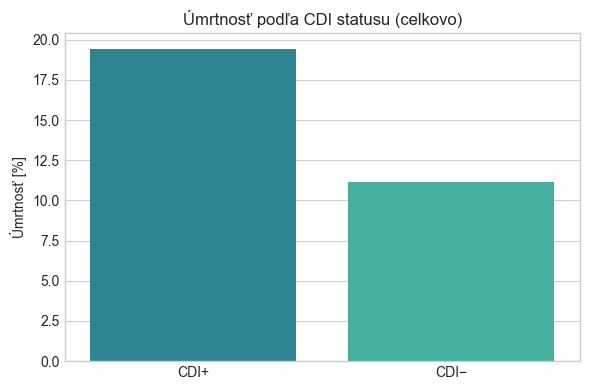

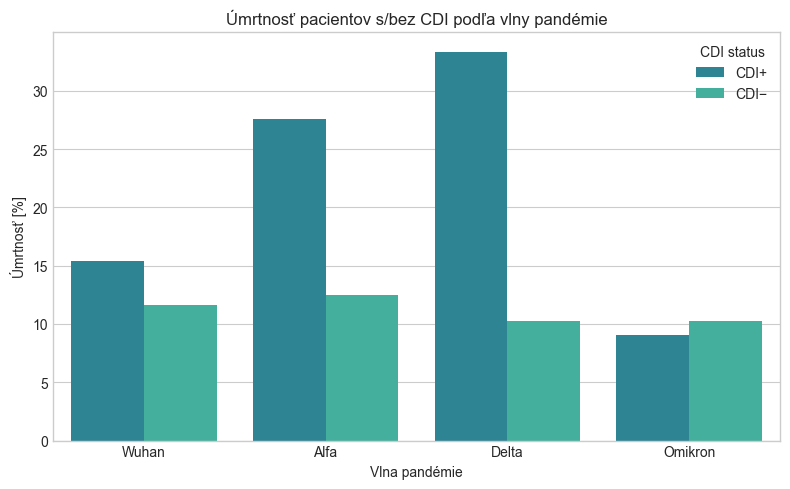

In [6]:
sev_col = "Závažnosť priebehu ochorenia"
if sev_col not in data.columns:
    print(f"WARN: Chýba stĺpec '{sev_col}', úmrtnosť sa preskočí.")
else:
    data[sev_col] = pd.to_numeric(data[sev_col], errors="coerce")

    overall = (
        data.groupby("CDI_status", observed=True)
        .agg(
            Pacienti=("Vlna", "count"),
            Umrtia=(sev_col, lambda x: np.sum(x == 3))
        )
        .reset_index()
    )
    overall["Umrtnost_%"] = (overall["Umrtia"] / overall["Pacienti"] * 100).round(2)
    display(overall)

    mortality_by_wave = (
        data.groupby(["Vlna", "CDI_status"], observed=True)
        .agg(
            Pacienti=("Vlna", "count"),
            Umrtia=(sev_col, lambda x: np.sum(x == 3))
        )
        .reset_index()
    )
    mortality_by_wave["Umrtnost_%"] = (mortality_by_wave["Umrtia"] / mortality_by_wave["Pacienti"] * 100).round(2)
    display(mortality_by_wave)

    plt.figure(figsize=(6,4))
    sns.barplot(data=overall, x="CDI_status", y="Umrtnost_%", palette=[PRIMARY, SECONDARY])
    plt.title("Úmrtnosť podľa CDI statusu (celkovo)")
    plt.ylabel("Úmrtnosť [%]")
    plt.xlabel("")
    plt.tight_layout()
    


    plt.figure(figsize=(8,5))
    sns.barplot(data=mortality_by_wave, x="Vlna", y="Umrtnost_%", hue="CDI_status", palette=[PRIMARY, SECONDARY])
    plt.title("Úmrtnosť pacientov s/bez CDI podľa vlny pandémie")
    plt.ylabel("Úmrtnosť [%]")
    plt.xlabel("Vlna pandémie")
    plt.legend(title="CDI status")
    plt.tight_layout()


## Demografia a CDI (vek, pohlavie)
- štatistiky veku podľa CDI,
- Mann–Whitney U test (vek CDI+ vs CDI−),
- boxplot veku,
- barplot pohlavie,
- violinplot vek podľa vĺn (CDI+ vs CDI−).

,count,mean,std,median,min,max
A04.7,,,,,,
CDI−,3745,64.78,15.78,66.0,19,100
CDI+,103,69.29,13.12,71.0,30,93


Mann–Whitney U test (vek): p = 0.004718


C:\Users\pavel\AppData\Local\Temp\ipykernel_11432\727747632.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="A04.7", y=age_col, palette=[PRIMARY, SECONDARY])
C:\Users\pavel\AppData\Local\Temp\ipykernel_11432\727747632.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sex, x=sex_col, y="CDI_%", palette=[PRIMARY, SECONDARY])


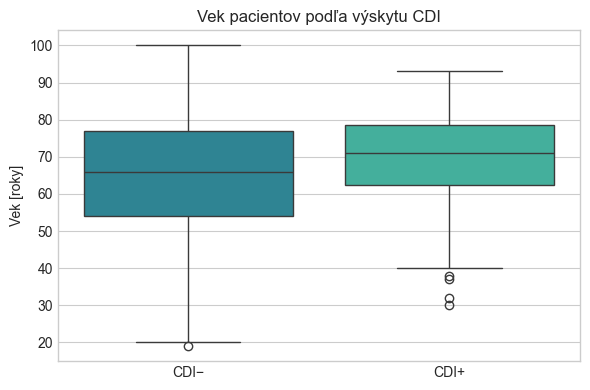

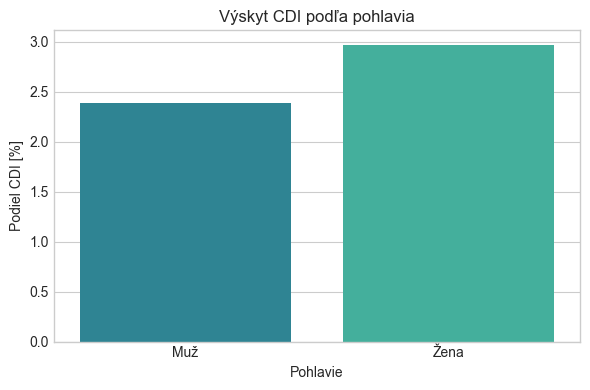

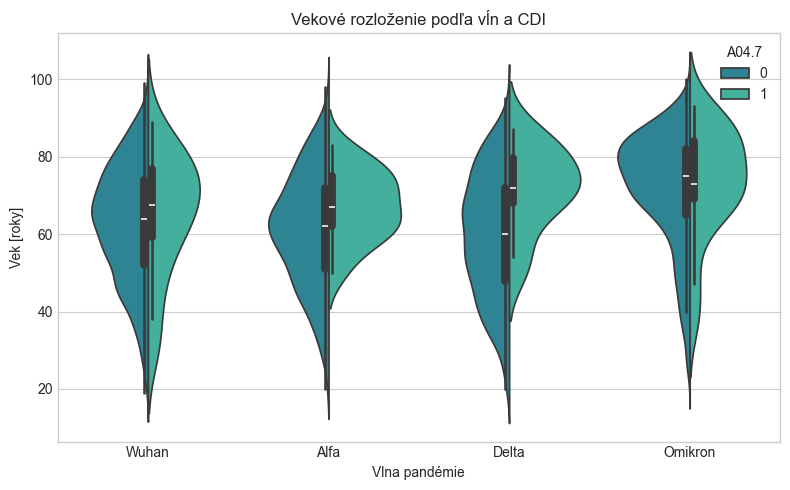

In [7]:
from scipy.stats import mannwhitneyu

age_col = "Vek"
sex_col = "Pohlavie"

if age_col in data.columns:
    data[age_col] = pd.to_numeric(data[age_col], errors="coerce")

    age_summary = (
        data.groupby("A04.7")[age_col]
        .agg(["count", "mean", "std", "median", "min", "max"])
        .round(2)
        .rename(index={0: "CDI−", 1: "CDI+"})
    )
    display(age_summary)

    cdi_yes = data.loc[data["A04.7"] == 1, age_col].dropna()
    cdi_no  = data.loc[data["A04.7"] == 0, age_col].dropna()
    if len(cdi_yes) > 0 and len(cdi_no) > 0:
        stat, pval = mannwhitneyu(cdi_yes, cdi_no, alternative="two-sided")
        print(f"Mann–Whitney U test (vek): p = {pval:.6f}")

    # Boxplot veku
    plt.figure(figsize=(6,4))
    sns.boxplot(data=data, x="A04.7", y=age_col, palette=[PRIMARY, SECONDARY])
    plt.xticks([0,1], ["CDI−", "CDI+"])
    plt.title("Vek pacientov podľa výskytu CDI")
    plt.ylabel("Vek [roky]")
    plt.xlabel("")
    plt.tight_layout()
else:
    print(f"WARN: Chýba stĺpec '{age_col}' – demografia (vek) sa preskočí.")

# Barplot pohlavia
if sex_col in data.columns:
    df_sex = (data.groupby(sex_col)["A04.7"].mean() * 100).reset_index().rename(columns={"A04.7": "CDI_%"}).dropna()
    if not df_sex.empty:
        plt.figure(figsize=(6,4))
        sns.barplot(data=df_sex, x=sex_col, y="CDI_%", palette=[PRIMARY, SECONDARY])
        plt.ylabel("Podiel CDI [%]")
        plt.title("Výskyt CDI podľa pohlavia")
        plt.tight_layout()
else:
    print(f"WARN: Chýba stĺpec '{sex_col}' – demografia (pohlavie) sa preskočí.")

# Violinplot vek podľa vĺn
if (age_col in data.columns) and (data["A04.7"].nunique() == 2):
    plt.figure(figsize=(8,5))
    sns.violinplot(
        data=data.dropna(subset=[age_col]),
        x="Vlna", y=age_col,
        hue="A04.7", split=True,
        palette=[PRIMARY, SECONDARY]
    )
    plt.title("Vekové rozloženie podľa vĺn a CDI")
    plt.ylabel("Vek [roky]")
    plt.xlabel("Vlna pandémie")
    plt.tight_layout()

## Výskyt CDI podľa vĺn
Vypočíta sa počet pacientov, počet CDI prípadov a podiel CDI (%) pre každú vlnu a vykreslia sa 2 grafy.

,Vlna,Pacienti,CDI_pripady,Podiel_CDI_%
0,Wuhan,1124,26,2.31
1,Alfa,824,29,3.52
2,Delta,649,15,2.31
3,Omikron,1251,33,2.64


C:\Users\pavel\AppData\Local\Temp\ipykernel_11432\751580585.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cdi_by_wave, x="Vlna", y="CDI_pripady", palette=[PRIMARY, SECONDARY])
C:\Users\pavel\AppData\Local\Temp\ipykernel_11432\751580585.py:10: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=cdi_by_wave, x="Vlna", y="CDI_pripady", palette=[PRIMARY, SECONDARY])
C:\Users\pavel\AppData\Local\Temp\ipykernel_11432\751580585.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cdi_by_wave, x="Vlna", y="Podiel_CDI_%", palette=[SECONDARY, PRIMARY])
C:\Users\pavel\AppData\Local\Temp\ipyk

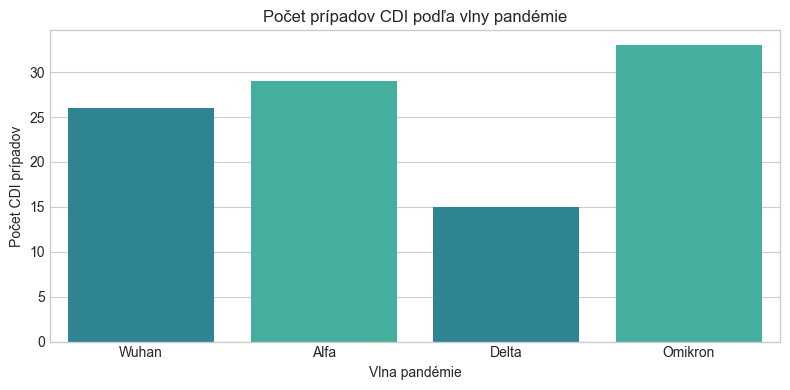

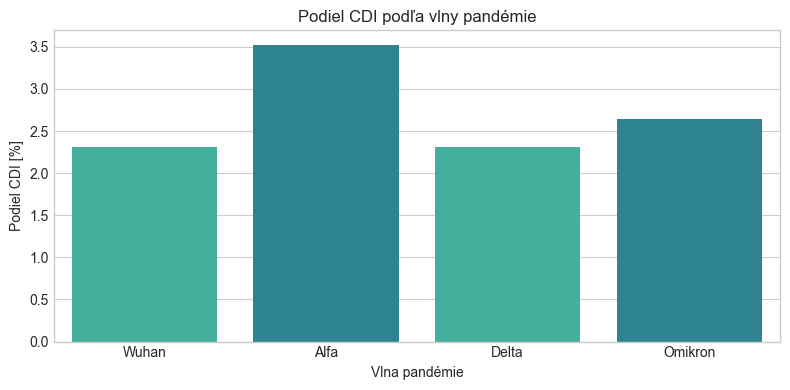

In [13]:
cdi_by_wave = (
    data.groupby("Vlna", observed=True)["A04.7"]
    .agg(Pacienti="count", CDI_pripady="sum")
    .reset_index()
)
cdi_by_wave["Podiel_CDI_%"] = (cdi_by_wave["CDI_pripady"] / cdi_by_wave["Pacienti"] * 100).round(2)
display(cdi_by_wave)

plt.figure(figsize=(8,4))
sns.barplot(data=cdi_by_wave, x="Vlna", y="CDI_pripady", palette=[PRIMARY, SECONDARY])
plt.title("Počet prípadov CDI podľa vlny pandémie")
plt.ylabel("Počet CDI prípadov")
plt.xlabel("Vlna pandémie")
plt.tight_layout()

plt.figure(figsize=(8,4))
sns.barplot(data=cdi_by_wave, x="Vlna", y="Podiel_CDI_%", palette=[SECONDARY, PRIMARY])
plt.title("Podiel CDI podľa vlny pandémie")
plt.ylabel("Podiel CDI [%]")
plt.xlabel("Vlna pandémie")
plt.tight_layout()

## Chronické ochorenia vs CDI
- Vypočíta sa podiel (%) výskytu komorbidity v CDI+ a CDI−.

,Ochorenie,CDI+_%,CDI−_%,Rozdiel_%
2,Kardiovaskulárne ochorenia,72.815534,61.789052,11.026482
0,Hypertenzia,66.990291,59.919893,7.070398
4,Renálne ochorenia,57.281553,39.145527,18.136026
1,Diabetes mellitus,29.126214,22.242991,6.883223
3,Chronické respiračné ochorenia,12.621359,10.493992,2.127367
6,Onkologické ochorenia,9.708738,7.503338,2.205400
5,Pečeňové ochorenia,5.825243,2.269693,3.555550
7,Imunosupresia,2.912621,4.352470,-1.439849


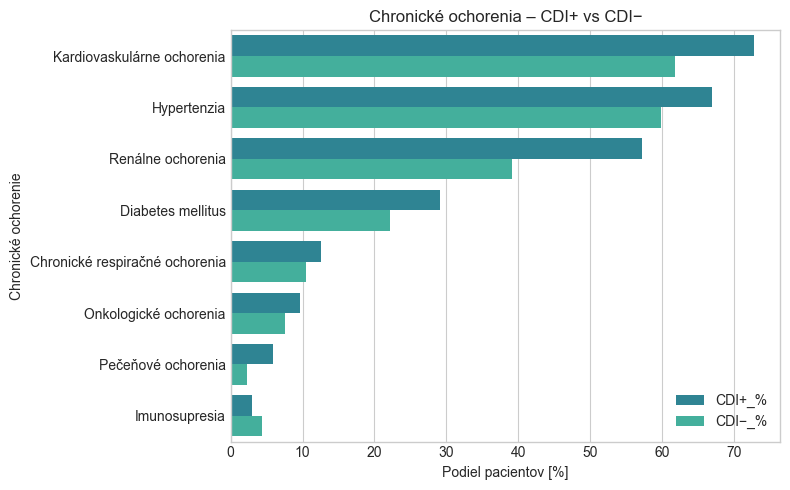

In [9]:
comorbid_cols = [
    "Hypertenzia", "Diabetes mellitus", "Kardiovaskulárne ochorenia",
    "Chronické respiračné ochorenia", "Renálne ochorenia",
    "Pečeňové ochorenia", "Onkologické ochorenia", "Imunosupresia",
]
existing_comorb = [c for c in comorbid_cols if c in data.columns]
if not existing_comorb:
    print("WARN: Žiadny stĺpcec sa nenašiel v dátach.")
else:
    summary = []
    for c in existing_comorb:
        pos = data.loc[data["A04.7"] == 1, c].mean() * 100
        neg = data.loc[data["A04.7"] == 0, c].mean() * 100
        summary.append([c, pos, neg, pos - neg])

    comorb_df = pd.DataFrame(summary, columns=["Ochorenie", "CDI+_%", "CDI−_%", "Rozdiel_%"])
    comorb_df = comorb_df.sort_values("CDI+_%", ascending=False)
    display(comorb_df)

    df_melt = comorb_df.melt(id_vars="Ochorenie", value_vars=["CDI+_%", "CDI−_%"],
                             var_name="Skupina", value_name="Podiel_%")

    plt.figure(figsize=(8,5))
    sns.barplot(data=df_melt, y="Ochorenie", x="Podiel_%", hue="Skupina", palette=[PRIMARY, SECONDARY])
    plt.title("Chronické ochorenia – CDI+ vs CDI−")
    plt.xlabel("Podiel pacientov [%]")
    plt.ylabel("Chronické ochorenie")
    plt.legend(title="")
    plt.tight_layout()

## Laboratórne parametre vs CDI (boxploty)
- Pre vybrané laby (napr. “first/last/max”) sa spraví numeric konverzia.
- Pri boxplotoch sa orežú extrémy (1–99 percentil).

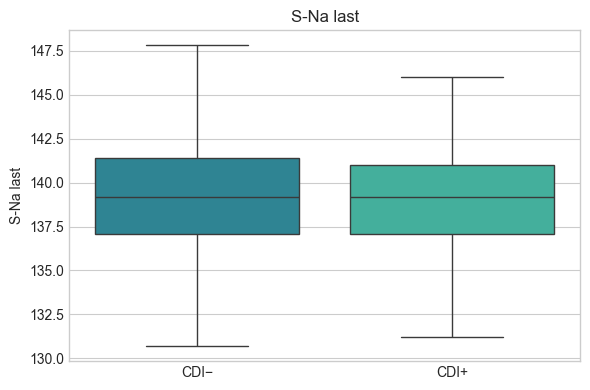

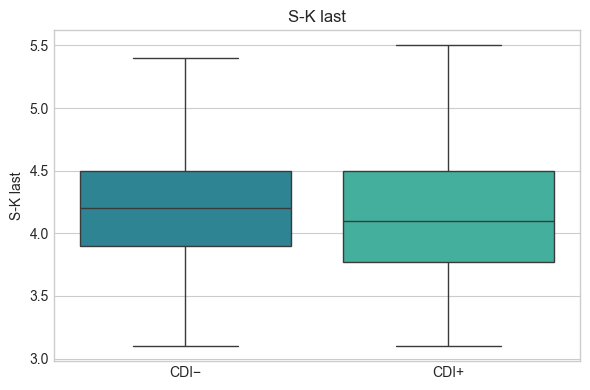

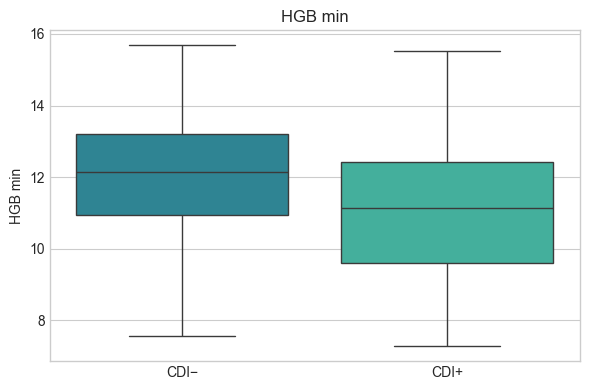

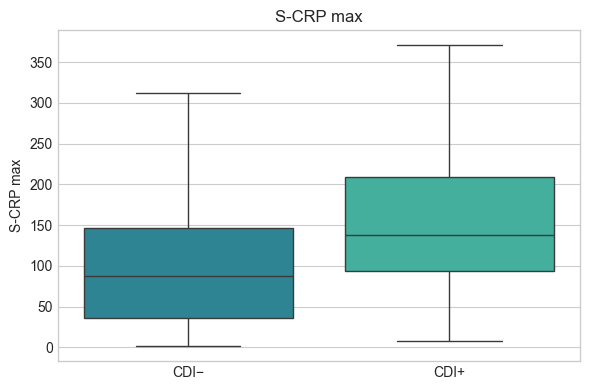

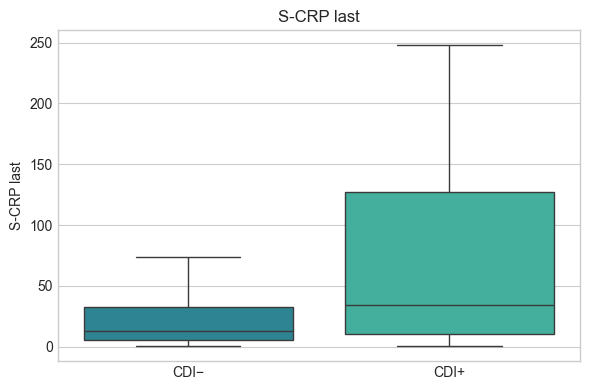

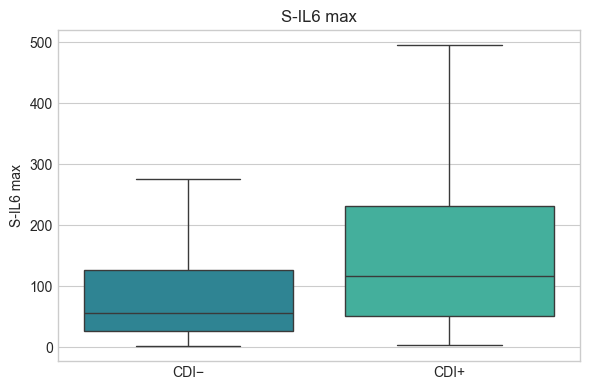

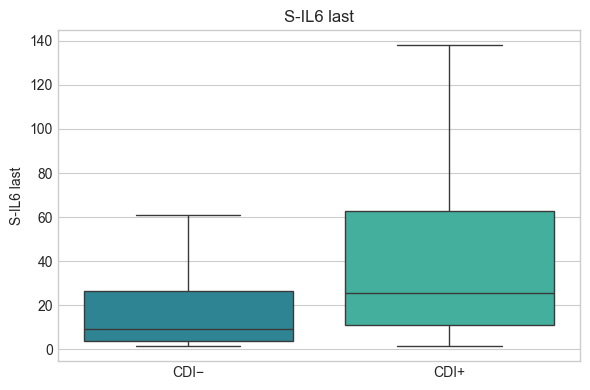

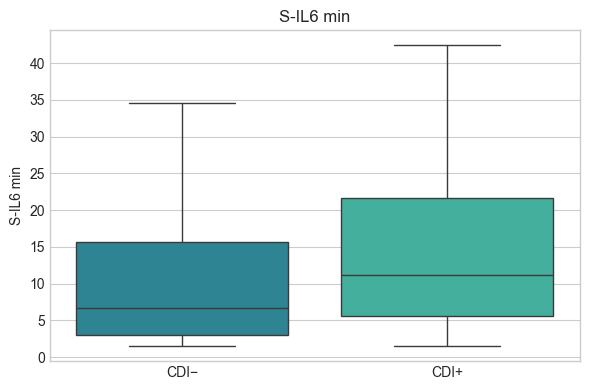

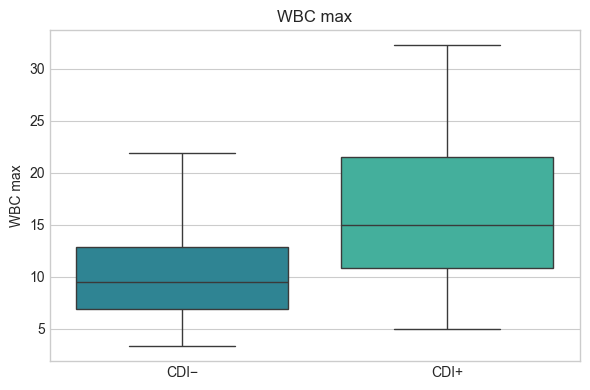

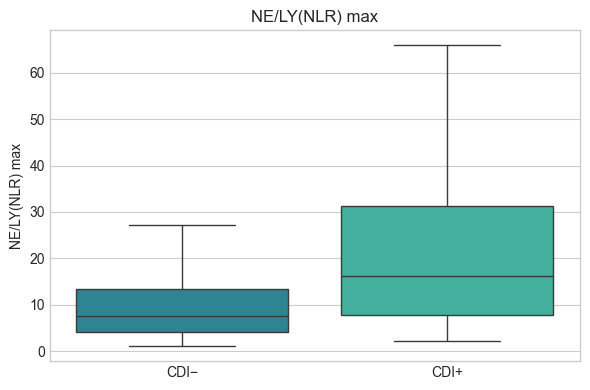

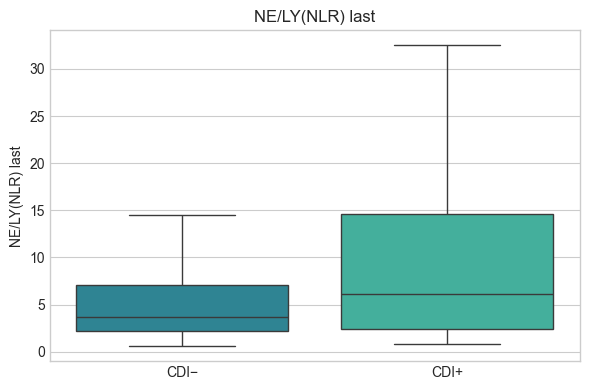

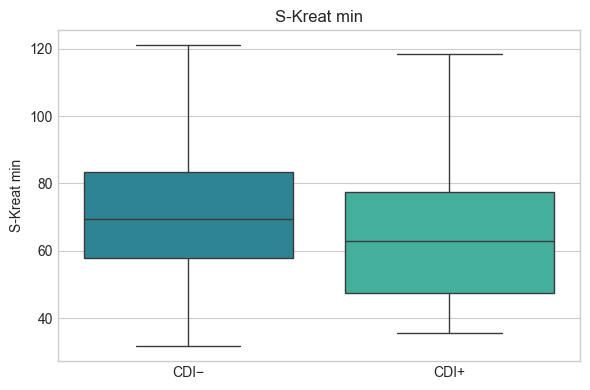

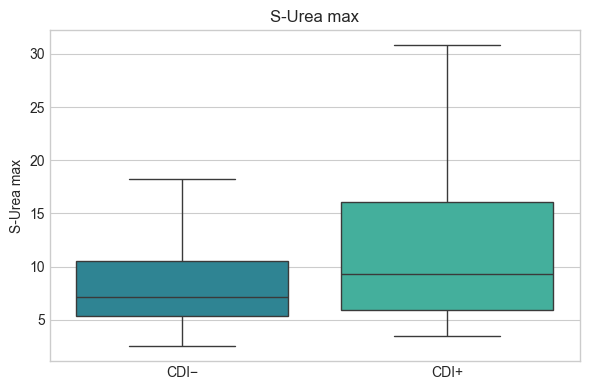

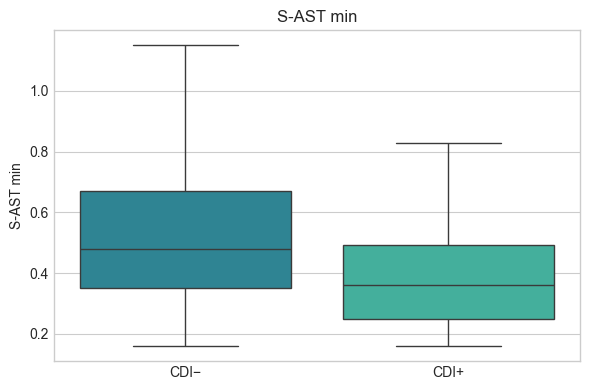

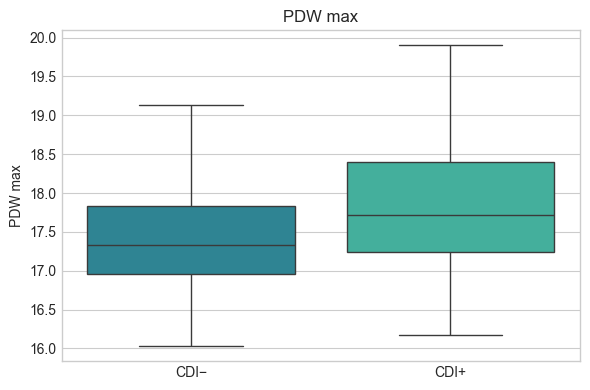

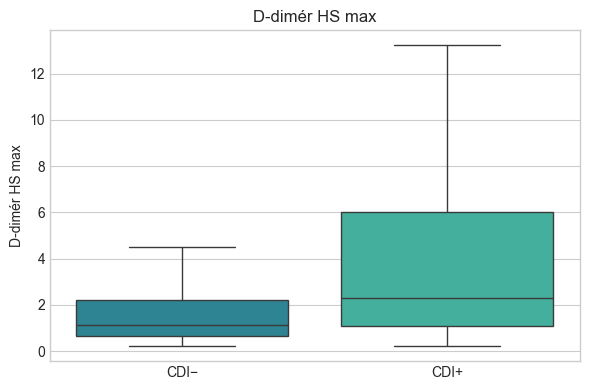

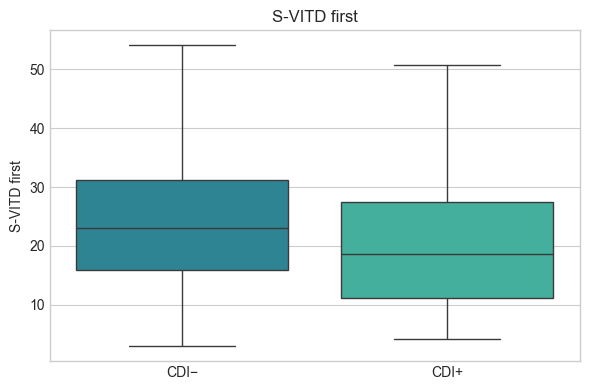

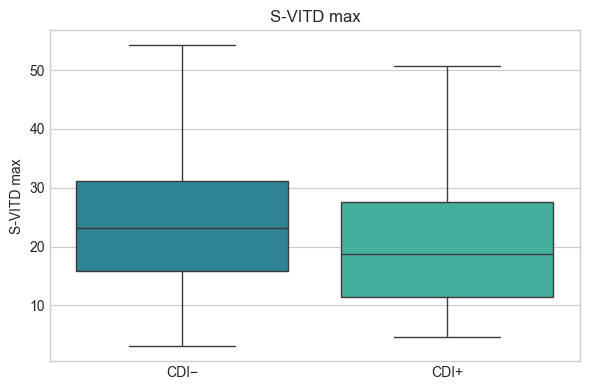

In [14]:
data_knn = pd.read_csv("data/data_clean_20_KNN.csv", sep=";", encoding="utf-8", low_memory=False)

# Zoznam laboratórnych stĺpcov 
lab_cols = [
    "S-Na last",
    "S-K last",
    "HGB min",
    "S-CRP max",
    "S-CRP last",
    "S-IL6 max",
    "S-IL6 last",
    "S-IL6 min",
    "WBC max",
    "NE/LY(NLR) max",
    "NE/LY(NLR) last",
    "S-Kreat min",
    "S-Urea max",
    "S-AST min",
    "PDW max",
    "D-dimér HS max",
    "S-VITD first",
    "S-VITD max"
]

def lab_boxplots_show(
    df: pd.DataFrame,
    lab_cols: list[str],
    target_col: str = "A04.7",
    clip_q: tuple[float, float] = (0.01, 0.99)
):
    existing = [c for c in lab_cols if c in df.columns]
    if not existing:
        print("WARN: Žiadny lab stĺpec sa nenašiel.")
        return

    for col in existing:
        tmp = df[[target_col, col]].copy()
        tmp[col] = pd.to_numeric(tmp[col], errors="coerce")
        tmp = tmp.dropna(subset=[target_col, col])

        if tmp.empty:
            print("Skipping (no data):", col)
            continue

        # orezanie extrémov podľa kvantilov
        low = tmp[col].quantile(clip_q[0])
        high = tmp[col].quantile(clip_q[1])
        tmp = tmp[(tmp[col] >= low) & (tmp[col] <= high)]

        if tmp.empty:
            print("Skipping (all clipped):", col)
            continue

        plt.figure(figsize=(6, 4))

        sns.boxplot(
            data=tmp,
            x=target_col,
            y=col,
            hue=target_col,
            palette=[PRIMARY, SECONDARY],
            dodge=False,
            showfliers=False
        )

        plt.xticks([0, 1], ["CDI−", "CDI+"])
        plt.title(col)
        plt.xlabel("")
        plt.legend([], [], frameon=False)
        plt.tight_layout()
        plt.show()
        plt.close()

lab_boxplots_show(data_knn, lab_cols)

## Lieky vs CDI – skupiny + detailné grafy
- Najprv sa porovnajú celé skupiny liekov (priemer výskytu v skupine).
- Následne sa pre každú skupinu vykreslí detailný graf podľa jednotlivých liekov.

,Skupina,CDI+_%,CDI−_%,Rozdiel_%
5,Iné (PPI),26.092233,16.899199,9.193034
2,Imuno- (tlmenie reakcie),32.686084,25.604510,7.081574
4,Antibiotiká,40.776699,33.894081,6.882618
6,Kašeľ,27.961165,23.839786,4.121379
1,Vitamíny,80.859917,77.451841,3.408076
3,Imuno+ (stimulácia),20.582524,18.937250,1.645275
7,Antikoagulanciá,23.883495,22.467290,1.416205
0,Antivirotiká,5.242718,7.204272,-1.961554


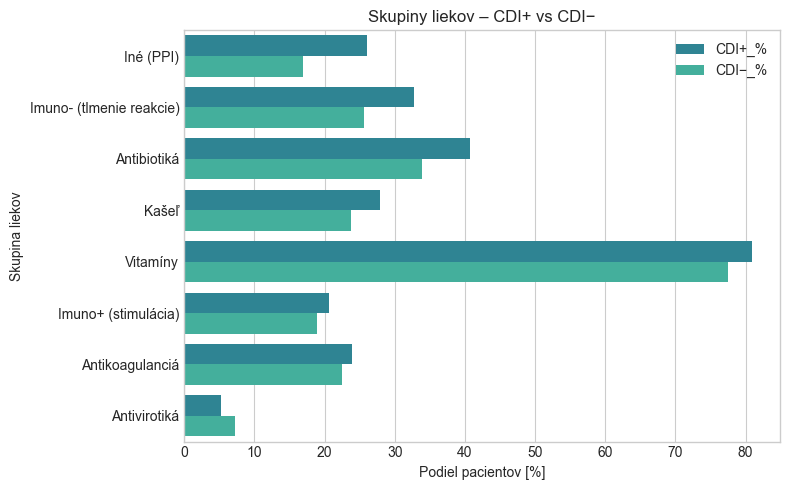

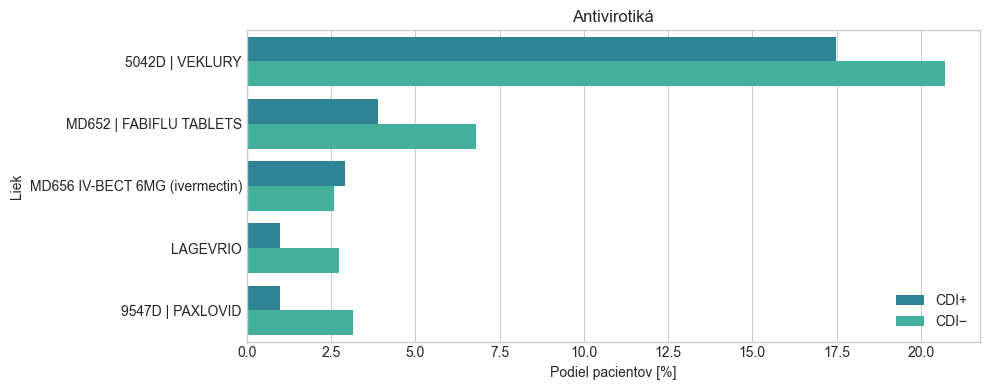

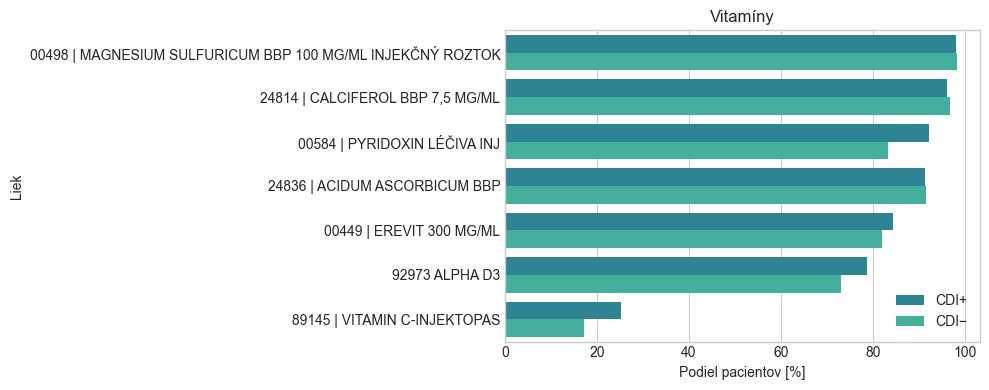

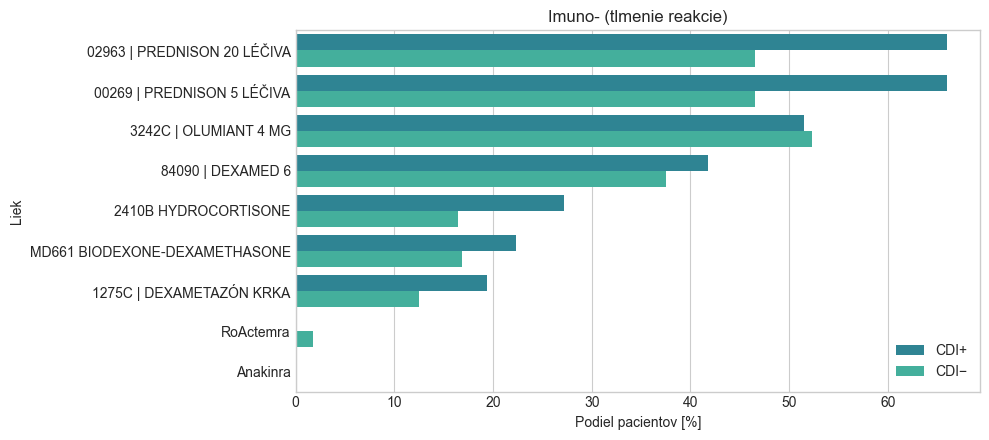

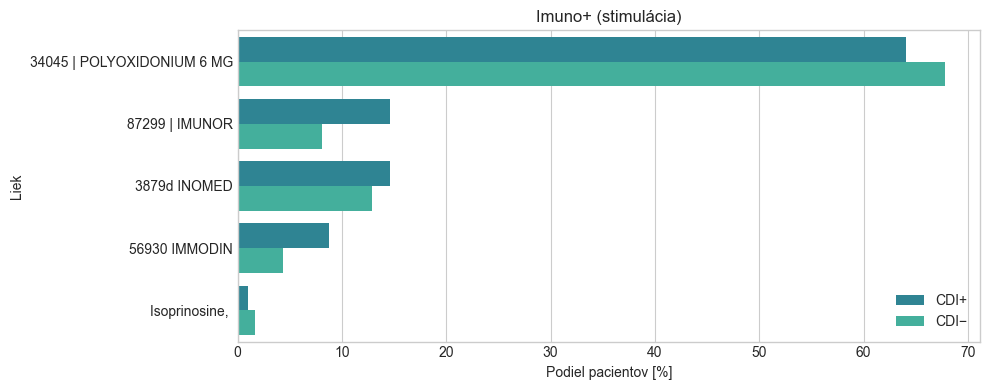

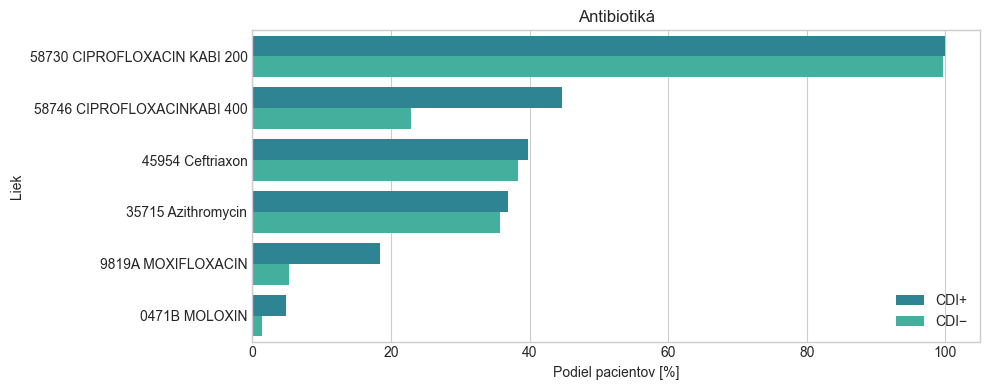

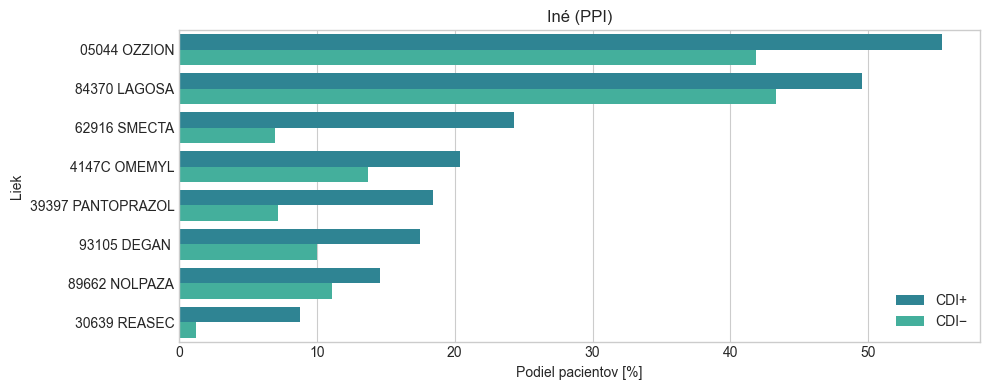

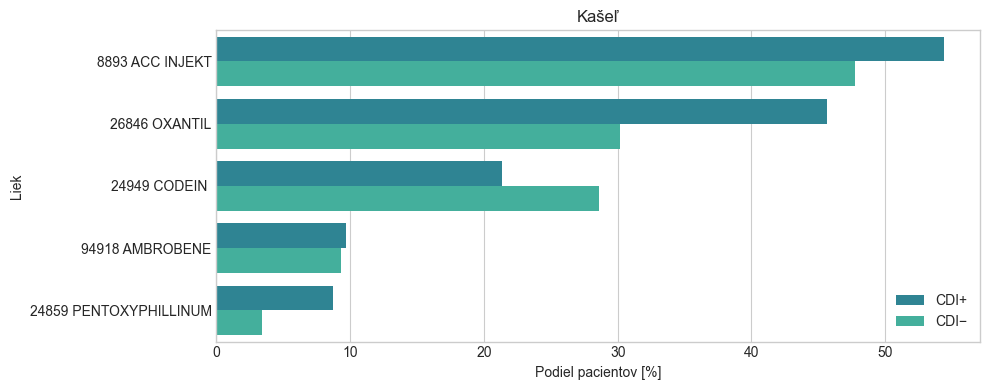

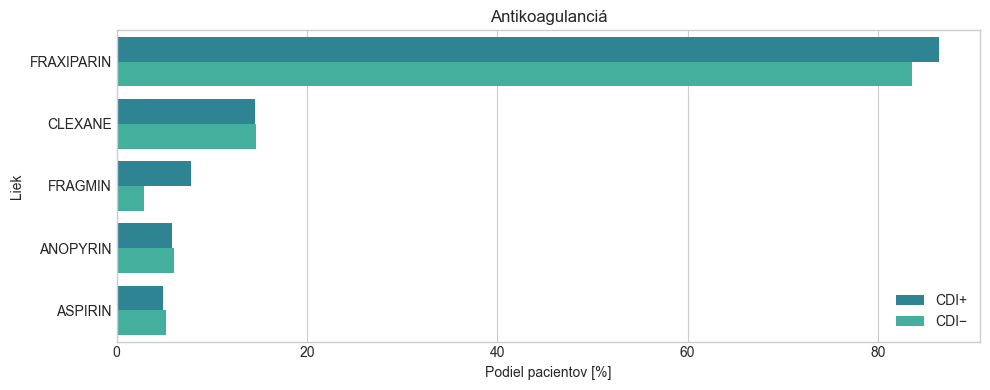

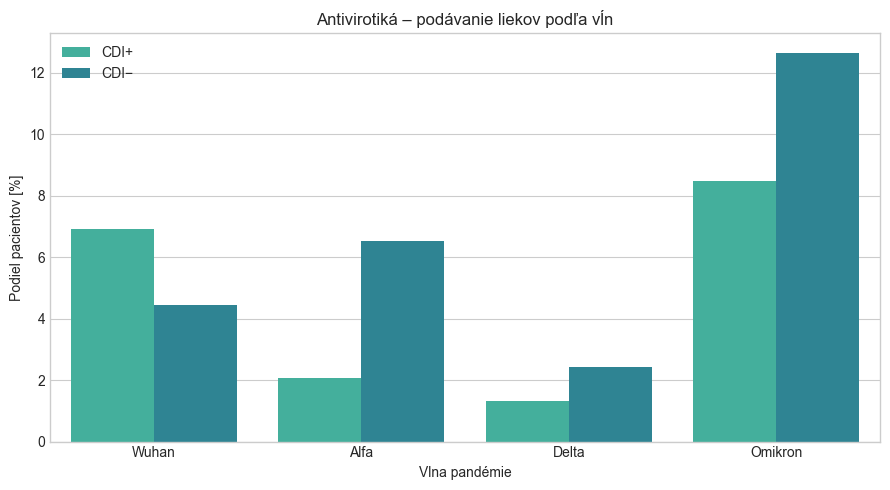

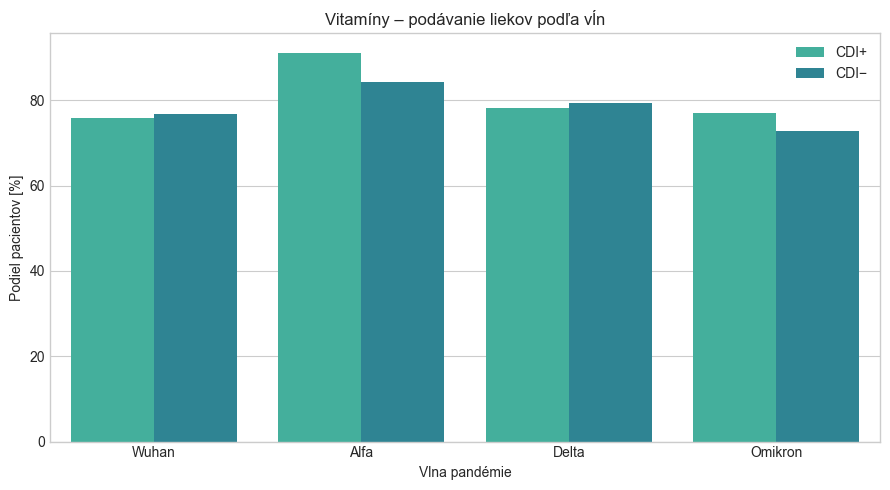

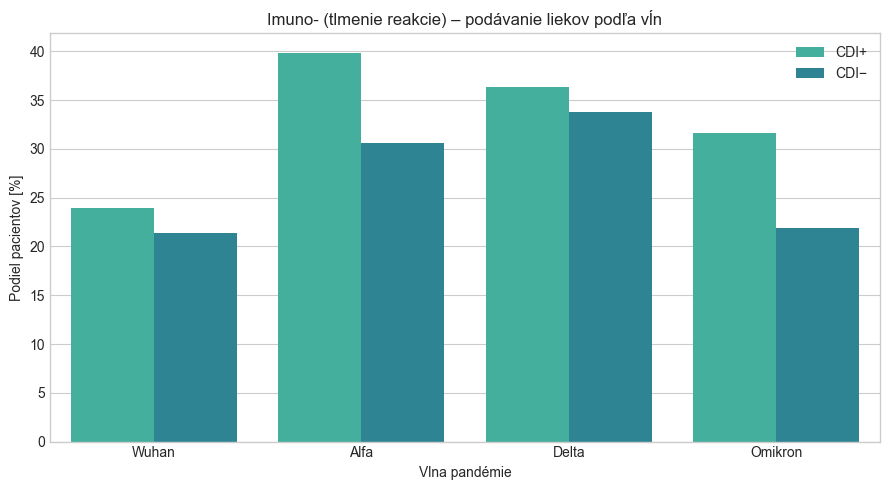

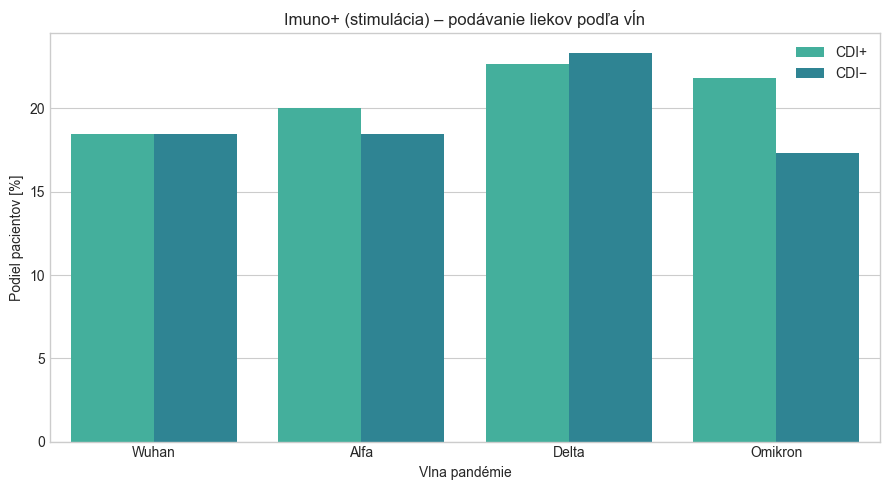

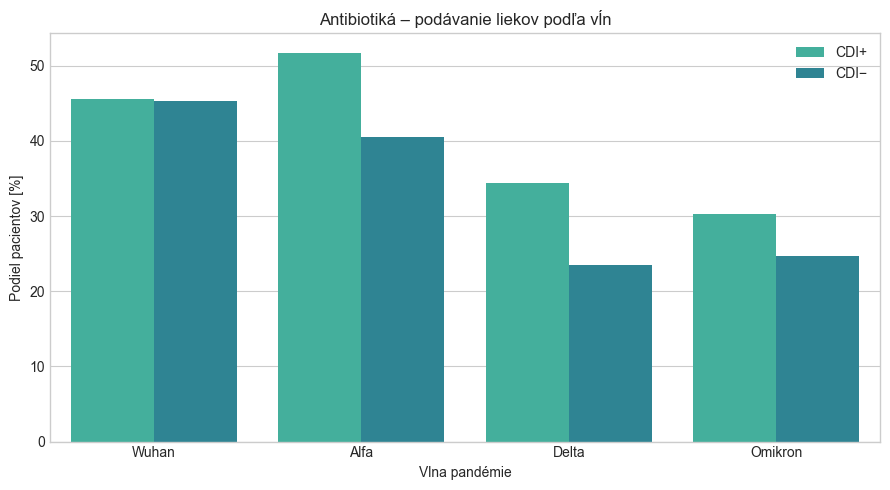

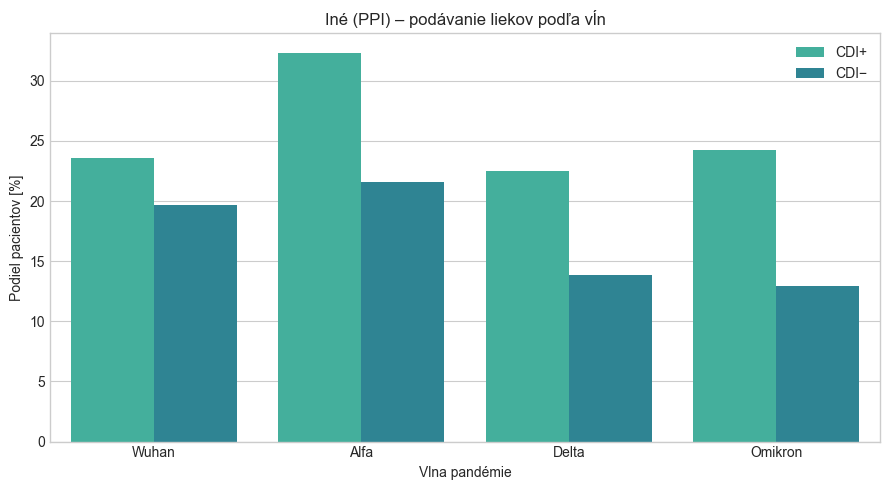

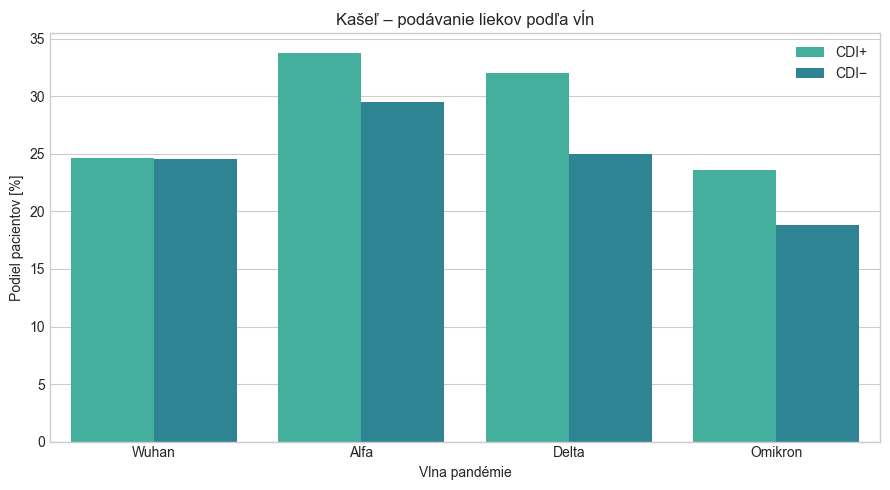

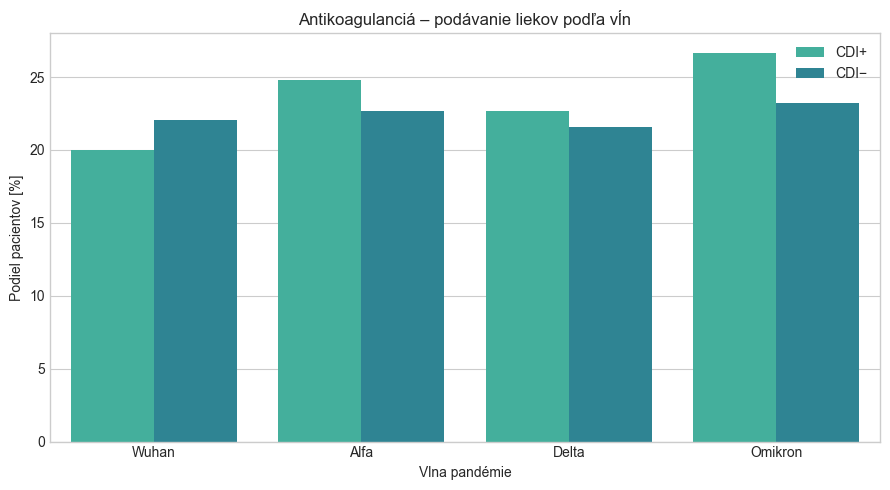

In [ ]:
drug_groups = {
    "Antivirotiká": [
        "MD652 | FABIFLU TABLETS", "MD656 IV-BECT 6MG (ivermectin)",
        "5042D | VEKLURY", "9547D | PAXLOVID", "LAGEVRIO"
    ],
    "Vitamíny": [
        "00584 | PYRIDOXIN LÉČIVA INJ", "24836 | ACIDUM ASCORBICUM BBP",
        "24814 | CALCIFEROL BBP 7,5 MG/ML", "00498 | MAGNESIUM SULFURICUM BBP 100 MG/ML INJEKČNÝ ROZTOK",
        "00449 | EREVIT 300 MG/ML", "89145 | VITAMIN C-INJEKTOPAS", "92973 ALPHA D3"
    ],
    "Imuno- (tlmenie reakcie)": [
        "02963 | PREDNISON 20 LÉČIVA", "00269 | PREDNISON 5 LÉČIVA", "84090 | DEXAMED 6",
        "1275C | DEXAMETAZÓN KRKA", "MD661 BIODEXONE-DEXAMETHASONE", "2410B HYDROCORTISONE",
        "3242C | OLUMIANT 4 MG", "Anakinra", "RoActemra"
    ],
    "Imuno+ (stimulácia)": [
        "34045 | POLYOXIDONIUM 6 MG", "87299 | IMUNOR", "56930 IMMODIN",
        "Isoprinosine, ", "3879d INOMED"
    ],
    "Antibiotiká": [
        "35715 Azithromycin", "45954 Ceftriaxon", "0471B MOLOXIN",
        "9819A MOXIFLOXACIN", "58730 CIPROFLOXACIN KABI 200", "58746 CIPROFLOXACINKABI 400"
    ],
    "Iné (PPI)": [
        "05044 OZZION", "4147C OMEMYL", "89662 NOLPAZA", "39397 PANTOPRAZOL",
        "62916 SMECTA", "30639 REASEC", "84370 LAGOSA", "93105 DEGAN "
    ],
    "Kašeľ": [
        "94918 AMBROBENE", "24859 PENTOXYPHILLINUM", "8893 ACC INJEKT",
        "24949 CODEIN ", "26846 OXANTIL"
    ],
    "Antikoagulanciá": [
        "FRAXIPARIN", "CLEXANE", "FRAGMIN", "ASPIRIN", "ANOPYRIN"
    ]
}

def safe_mean_percent(df: pd.DataFrame, cols: list[str], mask: pd.Series) -> float:
    if not cols:
        return np.nan
    x = df.loc[mask, cols].apply(pd.to_numeric, errors="coerce")
    if x.empty:
        return np.nan
    return float(x.mean().mean() * 100)

# Prehľad skupín
rows = []
for grp, cols in drug_groups.items():
    existing = [c for c in cols if c in data.columns]
    pos = safe_mean_percent(data, existing, data["A04.7"] == 1)
    neg = safe_mean_percent(data, existing, data["A04.7"] == 0)
    if np.isnan(pos) and np.isnan(neg):
        continue
    rows.append([grp, pos, neg, pos - neg])

drug_grp_df = pd.DataFrame(rows, columns=["Skupina", "CDI+_%", "CDI−_%", "Rozdiel_%"]).sort_values("Rozdiel_%", ascending=False)
display(drug_grp_df)

df_melt = drug_grp_df.melt(id_vars="Skupina", value_vars=["CDI+_%", "CDI−_%"],
                           var_name="CDI", value_name="Podiel_%")

plt.figure(figsize=(8,5))
sns.barplot(data=df_melt, y="Skupina", x="Podiel_%", hue="CDI", palette=[PRIMARY, SECONDARY])
plt.title("Skupiny liekov – CDI+ vs CDI−")
plt.xlabel("Podiel pacientov [%]")
plt.ylabel("Skupina liekov")
plt.legend(title="")
plt.tight_layout()

# Pre každú skupinu
for grp, cols in drug_groups.items():
    existing = [c for c in cols if c in data.columns]
    if not existing:
        print("Skipping:", grp, "(no columns)")
        continue

    rows = []
    for drug in existing:
        pos = float(data.loc[data["A04.7"] == 1, drug].mean() * 100)
        neg = float(data.loc[data["A04.7"] == 0, drug].mean() * 100)
        rows.append([drug, "CDI+", pos])
        rows.append([drug, "CDI−", neg])

    df = pd.DataFrame(rows, columns=["Liek", "CDI", "Podiel_%"])

    # sort podľa CDI+
    sort_map = df[df["CDI"] == "CDI+"][["Liek", "Podiel_%"]].set_index("Liek")["Podiel_%"].to_dict()
    df["sort_val"] = df["Liek"].map(sort_map)
    df = df.sort_values(["sort_val", "Liek"], ascending=False)

    plt.figure(figsize=(10, max(4, len(existing) * 0.5)))
    sns.barplot(data=df, y="Liek", x="Podiel_%", hue="CDI", palette=[PRIMARY, SECONDARY])
    plt.title(grp)
    plt.xlabel("Podiel pacientov [%]")
    plt.ylabel("Liek")
    plt.legend(title="")
    plt.tight_layout()

# Podľa vĺn 
for grp, cols in drug_groups.items():
    existing = [c for c in cols if c in data.columns]
    if not existing:
        continue

    rows = []
    for wave in WAVE_ORDER:
        dfw = data[data["Vlna"] == wave]
        if dfw.empty:
            continue

        pos = safe_mean_percent(dfw, existing, dfw["A04.7"] == 1)
        neg = safe_mean_percent(dfw, existing, dfw["A04.7"] == 0)
        rows.append([wave, "CDI+", pos])
        rows.append([wave, "CDI−", neg])

    df_plot = pd.DataFrame(rows, columns=["Vlna", "CDI", "Podiel_%"]).dropna()
    if df_plot.empty:
        continue

    plt.figure(figsize=(9, 5))
    sns.barplot(data=df_plot, x="Vlna", y="Podiel_%", hue="CDI", palette=[SECONDARY, PRIMARY])
    plt.title(f"{grp} – podávanie liekov podľa vĺn")
    plt.xlabel("Vlna pandémie")
    plt.ylabel("Podiel pacientov [%]")
    plt.legend(title="")
    plt.tight_layout()